# Loss Visualization
This notebook visualizes and compares Training Loss and Validation Loss flexibly across your fine-tuned checkpoints.
Replace the checkpoint paths below to compare loss curves across different training runs.

In [1]:
import json
import matplotlib.pyplot as plt
import os

def extract_loss_from_state(checkpoint_dir):
    state_file = os.path.join(checkpoint_dir, "trainer_state.json")
    if not os.path.exists(state_file):
        print(f"File not found: {state_file}")
        return {'train': ([], []), 'eval': ([], [])}

    with open(state_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    log_history = data.get("log_history", [])
    
    train_steps = []
    train_loss = []
    eval_steps = []
    eval_loss = []

    for log in log_history:
        if "loss" in log and "step" in log:
            train_steps.append(log["step"])
            train_loss.append(log["loss"])
        elif "eval_loss" in log and "step" in log:
            eval_steps.append(log["step"])
            eval_loss.append(log["eval_loss"])
            
    return {'train': (train_steps, train_loss), 'eval': (eval_steps, eval_loss)}

In [4]:
def plot_losses(checkpoint_dirs, title="Training and Validation Loss Comparison"):
    plt.figure(figsize=(12, 7))
    
    # Use green for train, red for validation
    train_color = 'green'
    val_color = 'red'
    
    for idx, cp_dir in enumerate(checkpoint_dirs):
        print(f"Reading data from: {cp_dir}")
        losses = extract_loss_from_state(cp_dir)
        
        # Build a short display label for the legend
        cp_name = os.path.basename(os.path.normpath(cp_dir))
        if cp_name.startswith('checkpoint'):
            parent_dir = os.path.basename(os.path.dirname(os.path.normpath(cp_dir)))
            cp_name = f"{parent_dir} ({cp_name})"
                
        train_steps, train_loss = losses['train']
        eval_steps, eval_loss = losses['eval']
        
        # Always plot solid lines, only color differs
        if train_steps:
            plt.plot(train_steps, train_loss, label=f"{cp_name} - Train", color=train_color, linestyle='-', marker='o', markersize=3, alpha=0.7)
        if eval_steps:
            plt.plot(eval_steps, eval_loss, label=f"{cp_name} - Validation", color=val_color, linestyle='-', marker='x', markersize=5, alpha=0.9)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Steps", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

### Specify Checkpoint Directories to Compare
Edit the `checkpoints_to_compare` list below to point to the checkpoints you want to visualize. You can add as many as you like.

Reading data from: ../models/qwen25-3b-v2/checkpoint-510


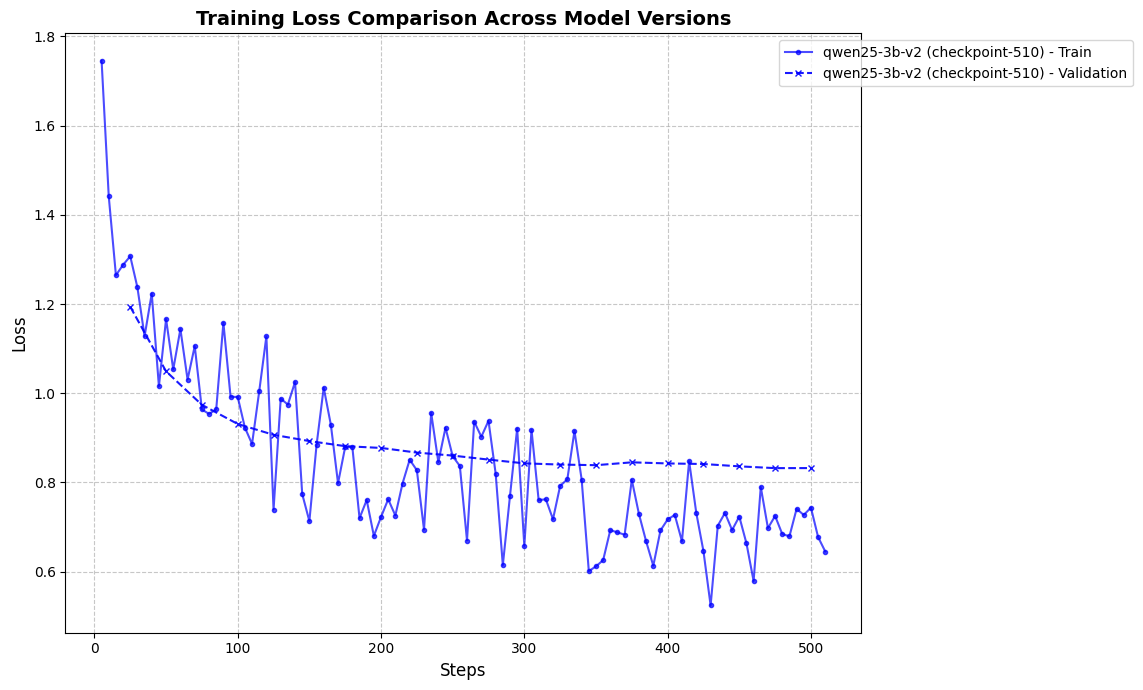

In [3]:
# List checkpoint directories to compare (relative paths from the notebooks folder to models)
checkpoints_to_compare = [
    "../models/qwen25-3b-v2/checkpoint-510"
]

plot_losses(checkpoints_to_compare, title="Training Loss Comparison Across Model Versions")